# Auswertung der RL-Experimente

Das Notebook liest die PyExperimenter-SQLite-Datenbank direkt ein. Es berücksichtigt nur abgeschlossene Runs und wertet Schrittverlauf, Episoden und Änderungserkennung aus.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
ROLLING_WINDOW = 100
CONFIDENCE_Z = 1.96

ALGORITHM_COLORS = {
    "dyna-q": "#56B4E9",
    "dyna-q-plus": "#E69F00",
    "local-change-dyna-q": "#4D4D4D",
    "q-learning": "#7B2CBF",
    "stability-aware-dyna-q": "#D55E00",
}
BEHAVIOR_COLORS = {
    "stationary": "#56B4E9",
    "noise": "#E69F00",
    "temporary": "#7B2CBF",
    "permanent": "#D55E00",
}

In [2]:
project_candidates = (Path.cwd(), *Path.cwd().parents)
PROJECT_ROOT = next(
    (
        path
        for path in project_candidates
        if (path / "experiments" / "pyexperimenter_results.db").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "experiments/pyexperimenter_results.db wurde nicht gefunden"
    )

DATABASE_PATH = PROJECT_ROOT / "experiments" / "pyexperimenter_results.db"
print(f"Datenbank: {DATABASE_PATH}")

Datenbank: C:\Users\Merlin\Documents\Uni\Master\SoSe2026\Reinforcement Learning\exam_project\structural-change-dyna-q\experiments\pyexperimenter_results.db


In [3]:
with sqlite3.connect(DATABASE_PATH) as connection:
    runs = pd.read_sql_query(
        "SELECT * FROM structural_change_experiments",
        connection,
    )
    steps = pd.read_sql_query(
        """
        SELECT
            step.*,
            run.algorithm,
            run.environment,
            run.world_behavior,
            run.seed,
            run.change_step,
            run.change_duration
        FROM structural_change_experiments__steps AS step
        JOIN structural_change_experiments AS run
            ON run.ID = step.experiment_id
        WHERE run.status = 'done'
        """,
        connection,
    )
    episodes = pd.read_sql_query(
        """
        SELECT
            episode.*,
            run.algorithm,
            run.environment,
            run.world_behavior,
            run.seed,
            run.change_step,
            run.change_duration
        FROM structural_change_experiments__episodes AS episode
        JOIN structural_change_experiments AS run
            ON run.ID = episode.experiment_id
        WHERE run.status = 'done'
        """,
        connection,
    )

for frame in (runs, steps, episodes):
    frame["scenario"] = (
        frame["environment"] + " - " + frame["world_behavior"]
    )

## Experimentstatus und Konfigurationen

In [4]:
status_summary = (
    runs.groupby(["algorithm", "scenario", "status"])
    .size()
    .rename("runs")
    .reset_index()
)
display(status_summary)

completed_configurations = (
    runs.loc[runs["status"] == "done"]
    .groupby(["algorithm", "scenario"], as_index=False)
    .agg(
        completed_seeds=("seed", "nunique"),
        change_step=("change_step", "first"),
        change_duration=("change_duration", "first"),
    )
)
display(completed_configurations)

,algorithm,scenario,status,runs
0,dyna-q,shortcut - permanent,done,50
1,dyna-q,two-routes - noise,done,50
2,dyna-q,two-routes - permanent,done,50
3,dyna-q,two-routes - stationary,done,50
4,dyna-q,two-routes - temporary,done,50
5,dyna-q-plus,shortcut - permanent,done,50
6,dyna-q-plus,two-routes - noise,done,50
7,dyna-q-plus,two-routes - permanent,done,50
8,dyna-q-plus,two-routes - stationary,done,50
9,dyna-q-plus,two-routes - temporary,done,50


,algorithm,scenario,completed_seeds,change_step,change_duration
0,dyna-q,shortcut - permanent,50,1000.0,NaN
1,dyna-q,two-routes - noise,50,1000.0,500.0
2,dyna-q,two-routes - permanent,50,1000.0,NaN
3,dyna-q,two-routes - stationary,50,NaN,NaN
4,dyna-q,two-routes - temporary,50,1000.0,500.0
5,dyna-q-plus,shortcut - permanent,50,1000.0,NaN
6,dyna-q-plus,two-routes - noise,50,1000.0,500.0
7,dyna-q-plus,two-routes - permanent,50,1000.0,NaN
8,dyna-q-plus,two-routes - stationary,50,NaN,NaN
9,dyna-q-plus,two-routes - temporary,50,1000.0,500.0


## Rewardverlauf pro Schritt

Der kumulierte Reward sinkt bei überwiegend negativen Schritt-Rewards zwangsläufig. Deshalb wird hier der gleitende mittlere Reward pro Schritt gezeigt. Die Fläche ist das 95-%-Konfidenzintervall über die Seeds.

In [5]:
steps = steps.sort_values(["experiment_id", "global_step"]).copy()
steps["phase"] = np.select(
    [
        steps["world_behavior"].eq("stationary"),
        steps["global_step"] <= steps["change_step"],
        steps["world_behavior"].isin(["temporary", "noise"])
        & (steps["global_step"] <= (
            steps["change_step"] + steps["change_duration"]
        )),
    ],
    ["stationary", "before_change", "during_change"],
    default="after_change",
)
steps["rolling_reward"] = (
    steps.groupby("experiment_id")["reward"]
    .transform(
        lambda rewards: rewards.rolling(
            ROLLING_WINDOW,
            min_periods=max(1, ROLLING_WINDOW // 2),
        ).mean()
    )
)

step_curve = (
    steps.groupby(["algorithm", "scenario", "global_step"])[
        "rolling_reward"
    ]
    .agg(["mean", "std", "count"])
    .reset_index()
)
step_curve["ci"] = (
    CONFIDENCE_Z
    * step_curve["std"].fillna(0.0)
    / np.sqrt(step_curve["count"])
)

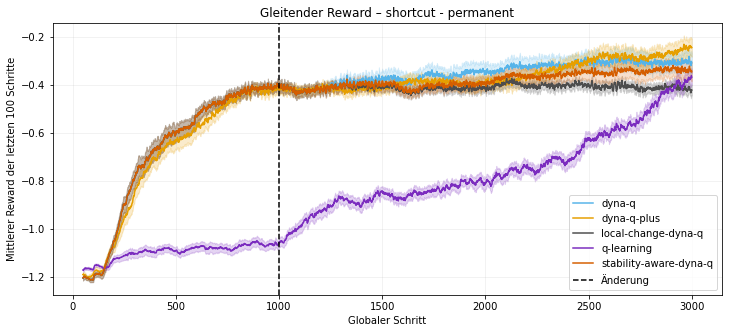

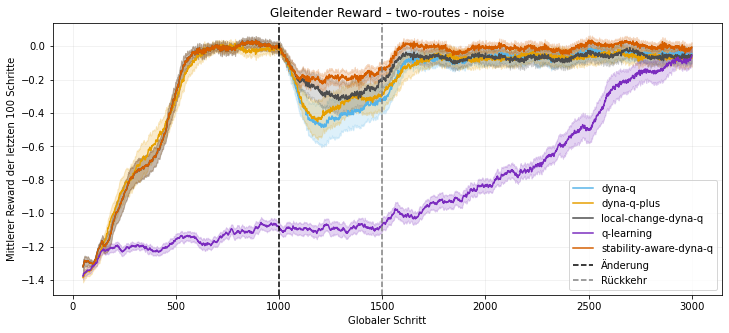

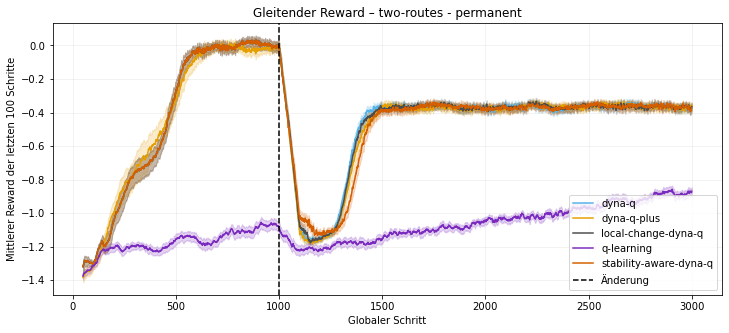

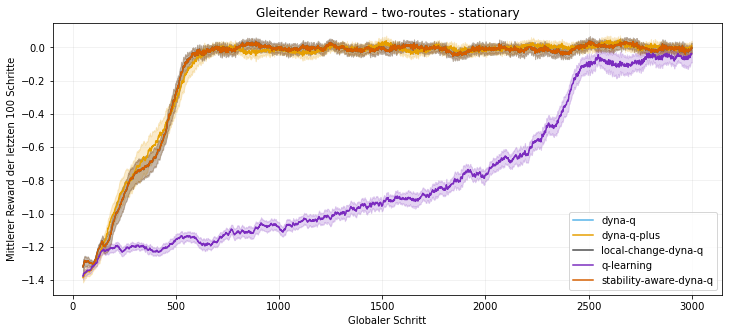

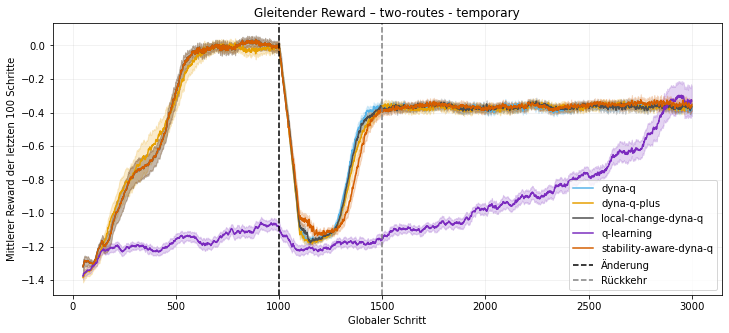

In [6]:
for scenario, scenario_curve in step_curve.groupby("scenario"):
    figure, axis = plt.subplots(figsize=(12, 5))

    for algorithm, algorithm_curve in scenario_curve.groupby("algorithm"):
        x = algorithm_curve["global_step"].to_numpy()
        mean = algorithm_curve["mean"].to_numpy()
        ci = algorithm_curve["ci"].to_numpy()
        color = ALGORITHM_COLORS[algorithm]
        axis.plot(x, mean, color=color, label=algorithm)
        axis.fill_between(
            x, mean - ci, mean + ci, color=color, alpha=0.2
        )

    scenario_runs = runs.loc[
        (runs["scenario"] == scenario)
        & (runs["status"] == "done")
    ]
    change_step = scenario_runs["change_step"].iloc[0]
    if pd.notna(change_step):
        change_step = int(change_step)
        change_duration = scenario_runs["change_duration"].iloc[0]
        axis.axvline(
            change_step,
            color="black",
            linestyle="--",
            label="Änderung",
        )
        if pd.notna(change_duration):
            change_end = change_step + int(change_duration)
            axis.axvline(
                change_end,
                color="grey",
                linestyle="--",
                label="Rückkehr",
            )
    axis.set(
        title=f"Gleitender Reward – {scenario}",
        xlabel="Globaler Schritt",
        ylabel=f"Mittlerer Reward der letzten {ROLLING_WINDOW} Schritte",
    )
    axis.legend()
    axis.grid(alpha=0.2)
    plt.show()

In [7]:
NOISE_START_STEP = 1000
NOISE_END_STEP = 1500
REFERENCE_START_STEP = 801
RECOVERY_TOLERANCE = 0.05
RECOVERY_STABILITY_STEPS = 100

noise_runs = steps.loc[
    (steps["environment"] == "two-routes")
    & steps["world_behavior"].eq("noise")
    & steps["change_duration"].eq(500)
]

noise_phase = noise_runs.loc[
    (noise_runs["global_step"] > NOISE_START_STEP)
    & (noise_runs["global_step"] <= NOISE_END_STEP)
]

variance_per_step = (
    noise_phase.groupby(["algorithm", "global_step"])
    ["rolling_reward"]
    .agg(
        mean_reward="mean",
        reward_variance="var",
        reward_std="std",
        seeds="count",
    )
    .reset_index()
)

variability_summary = (
    variance_per_step.groupby("algorithm")
    .agg(
        average_variance=("reward_variance", "mean"),
        average_std=("reward_std", "mean"),
        worst_std=("reward_std", "max"),
    )
)

metric_records = []

for experiment_id, run_steps in noise_runs.groupby("experiment_id"):
    run_steps = run_steps.sort_values("global_step")
    reference_steps = run_steps.loc[
        run_steps["global_step"].between(
            REFERENCE_START_STEP,
            NOISE_START_STEP,
        )
    ]
    noise_steps = run_steps.loc[
        (run_steps["global_step"] > NOISE_START_STEP)
        & (run_steps["global_step"] <= NOISE_END_STEP)
    ]
    recovery_steps = run_steps.loc[
        run_steps["global_step"] > NOISE_END_STEP
    ]

    baseline_reward = reference_steps["reward"].mean()
    baseline_rolling_reward = reference_steps["rolling_reward"].mean()
    recovery_threshold = (
        baseline_rolling_reward - RECOVERY_TOLERANCE
    )
    stable_recovery = (
        recovery_steps["rolling_reward"].ge(recovery_threshold)
        .rolling(
            RECOVERY_STABILITY_STEPS,
            min_periods=RECOVERY_STABILITY_STEPS,
        )
        .sum()
        .eq(RECOVERY_STABILITY_STEPS)
    )
    stable_window_ends = np.flatnonzero(stable_recovery.to_numpy())

    recovered = stable_window_ends.size > 0
    recovery_duration = np.nan
    if recovered:
        recovery_start_index = (
            stable_window_ends[0] - RECOVERY_STABILITY_STEPS + 1
        )
        recovery_start_step = recovery_steps.iloc[recovery_start_index][
            "global_step"
        ]
        recovery_duration = recovery_start_step - NOISE_END_STEP

    first_step = run_steps.iloc[0]
    metric_records.append(
        {
            "algorithm": first_step["algorithm"],
            "seed": first_step["seed"],
            "average_reward": noise_steps["reward"].mean(),
            "cumulative_reward_loss": (
                baseline_reward * len(noise_steps)
                - noise_steps["reward"].sum()
            ),
            "strongest_drop": max(
                0.0,
                baseline_rolling_reward
                - noise_steps["rolling_reward"].min(),
            ),
            "recovery_steps": recovery_duration,
            "recovered": recovered,
        }
    )

per_seed_metrics = pd.DataFrame(metric_records)
metric_summary = per_seed_metrics.groupby("algorithm").agg(
    average_reward=("average_reward", "mean"),
    average_cumulative_reward_loss=("cumulative_reward_loss", "mean"),
    average_strongest_drop=("strongest_drop", "mean"),
    average_recovery_steps=("recovery_steps", "mean"),
    recovery_rate=("recovered", "mean"),
    seeds=("seed", "nunique"),
)

stability_summary = metric_summary.join(variability_summary).sort_values(
    "average_reward",
    ascending=False,
)

display(stability_summary)

,average_reward,average_cumulative_reward_loss,average_strongest_drop,average_recovery_steps,recovery_rate,seeds,average_variance,average_std,worst_std
algorithm,,,,,,,,,
stability-aware-dyna-q,-0.18420,94.00,0.501221,242.900000,0.80,50,0.022539,0.149334,0.186087
dyna-q-plus,-0.33892,161.66,0.765089,271.756757,0.74,50,0.095748,0.297714,0.399947
dyna-q,-0.38276,193.28,0.900421,293.666667,0.66,50,0.113818,0.325722,0.438740
q-learning,-1.08652,2.21,0.231502,70.380000,1.00,50,0.016221,0.126974,0.149806


## Verhalten des Stability-Mechanismus

Die folgenden Diagramme betrachten gezielt den Übergang vor dem Hazard: Zustand `(1, 4)` mit Aktion `right`. Modell-Stability ist das größte normalisierte Evidence-Gewicht und zeigt, wie eindeutig eine Transition dominiert. Die Stability der beobachteten Transition ist zugleich ihr Gewicht beim realen Q-Update. Die Werte werden nur aktualisiert, wenn der Agent diesen Übergang ausführt. Zwischen zwei Besuchen bleibt der interne Zustand unverändert und wird deshalb vorwärts fortgeschrieben. Die schwarze Linie markiert den Beginn der Änderung, die graue Linie das Ende der Noise- beziehungsweise Temporary-Phase.

In [8]:
MECHANISM_ALGORITHM = "stability-aware-dyna-q"
MECHANISM_ENVIRONMENT = "two-routes"
MECHANISM_STATE = (1, 4)
MECHANISM_ACTION = "right"
MECHANISM_BEHAVIORS = [
    "stationary",
    "noise",
    "temporary",
    "permanent",
]
MISMATCH_WINDOW = 100
MECHANISM_METRICS = [
    "stability_score",
    "observed_transition_stability",
    "candidate_count",
]

mechanism_observations = steps.loc[
    steps["algorithm"].eq(MECHANISM_ALGORITHM)
    & steps["environment"].eq(MECHANISM_ENVIRONMENT)
    & steps["world_behavior"].isin(MECHANISM_BEHAVIORS)
    & steps["state_row"].eq(MECHANISM_STATE[0])
    & steps["state_column"].eq(MECHANISM_STATE[1])
    & steps["action"].eq(MECHANISM_ACTION)
].copy()

mechanism_timelines = []

for experiment_id, observations in mechanism_observations.groupby(
    "experiment_id"
):
    observations = observations.sort_values("global_step")
    last_global_step = int(
        steps.loc[
            steps["experiment_id"].eq(experiment_id),
            "global_step",
        ].max()
    )
    global_steps = pd.RangeIndex(
        1,
        last_global_step + 1,
        name="global_step",
    )
    timeline = (
        observations.set_index("global_step")[MECHANISM_METRICS]
        .reindex(global_steps)
        .ffill()
        .reset_index()
    )

    mismatch_events = pd.Series(0.0, index=global_steps)
    mismatch_steps = observations.loc[
        observations["model_mismatch"].eq(1),
        "global_step",
    ]
    mismatch_events.loc[mismatch_steps] = 1.0

    run = observations.iloc[0]
    timeline["experiment_id"] = experiment_id
    timeline["seed"] = run["seed"]
    timeline["world_behavior"] = run["world_behavior"]
    timeline["mismatch_event"] = mismatch_events.to_numpy()
    timeline["mismatches_in_window"] = (
        mismatch_events.rolling(MISMATCH_WINDOW, min_periods=1)
        .sum()
        .to_numpy()
    )
    mechanism_timelines.append(timeline)

mechanism_timeline = pd.concat(
    mechanism_timelines,
    ignore_index=True,
)

display(
    mechanism_observations.groupby("world_behavior")
    .agg(
        seeds=("seed", "nunique"),
        transition_visits=("global_step", "size"),
        mismatches=("model_mismatch", "sum"),
    )
)

,seeds,transition_visits,mismatches
world_behavior,,,
noise,50,13762,468.0
permanent,50,3997,350.0
stationary,50,13787,0.0
temporary,50,4105,381.0


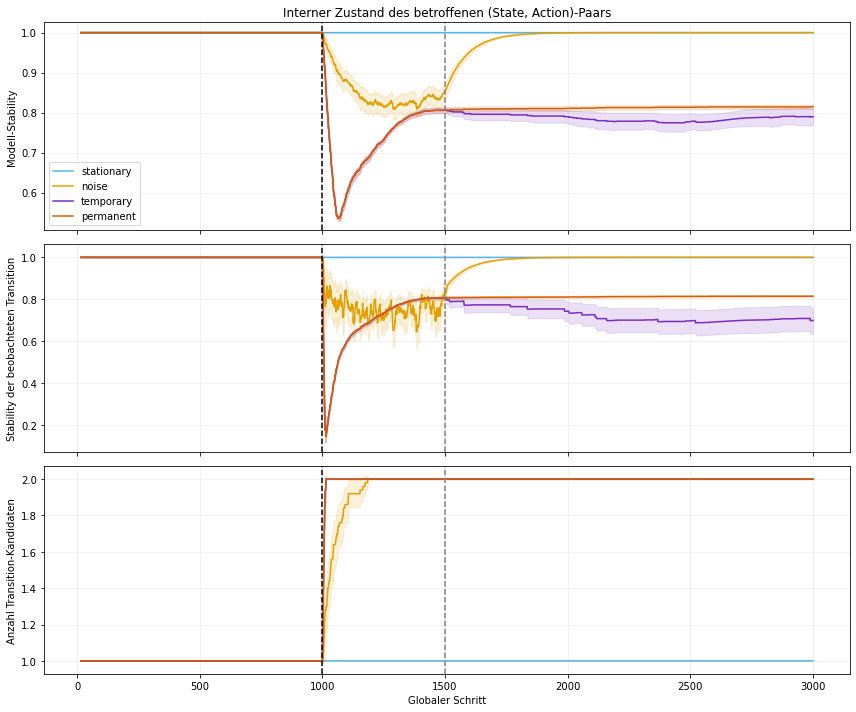

In [9]:
metric_labels = {
    "stability_score": "Modell-Stability",
    "observed_transition_stability": (
        "Stability der beobachteten Transition"
    ),
    "candidate_count": "Anzahl Transition-Kandidaten",
}

figure, axes = plt.subplots(
    len(MECHANISM_METRICS),
    1,
    figsize=(12, 10),
    sharex=True,
)

for axis, metric in zip(axes, MECHANISM_METRICS):
    metric_curve = (
        mechanism_timeline.groupby(
            ["world_behavior", "global_step"]
        )[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    metric_curve["ci"] = (
        CONFIDENCE_Z
        * metric_curve["std"].fillna(0.0)
        / np.sqrt(metric_curve["count"])
    )

    for behavior in MECHANISM_BEHAVIORS:
        curve = metric_curve.loc[
            metric_curve["world_behavior"].eq(behavior)
        ]
        x = curve["global_step"].to_numpy()
        mean = curve["mean"].to_numpy()
        ci = curve["ci"].to_numpy()
        color = BEHAVIOR_COLORS[behavior]
        axis.plot(x, mean, color=color, label=behavior)
        axis.fill_between(
            x, mean - ci, mean + ci, color=color, alpha=0.15
        )

    axis.axvline(1000, color="black", linestyle="--")
    axis.axvline(1500, color="grey", linestyle="--")
    axis.set_ylabel(metric_labels[metric])
    axis.grid(alpha=0.2)

axes[0].legend()
axes[0].set_title(
    "Interner Zustand des betroffenen (State, Action)-Paars"
)
axes[-1].set_xlabel("Globaler Schritt")
figure.tight_layout()
plt.show()

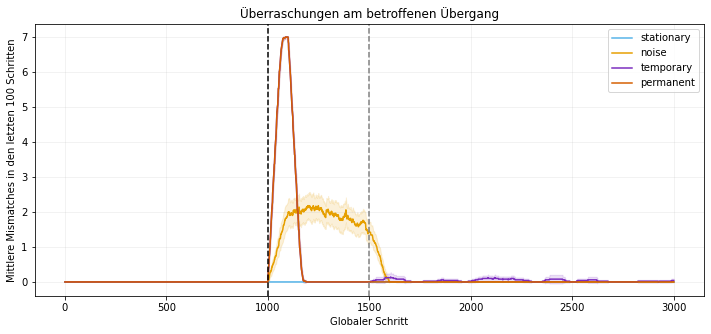

In [10]:
mismatch_curve = (
    mechanism_timeline.groupby(
        ["world_behavior", "global_step"]
    )["mismatches_in_window"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
mismatch_curve["ci"] = (
    CONFIDENCE_Z
    * mismatch_curve["std"].fillna(0.0)
    / np.sqrt(mismatch_curve["count"])
)

figure, axis = plt.subplots(figsize=(12, 5))

for behavior in MECHANISM_BEHAVIORS:
    curve = mismatch_curve.loc[
        mismatch_curve["world_behavior"].eq(behavior)
    ]
    x = curve["global_step"].to_numpy()
    mean = curve["mean"].to_numpy()
    ci = curve["ci"].to_numpy()
    color = BEHAVIOR_COLORS[behavior]
    axis.plot(x, mean, color=color, label=behavior)
    axis.fill_between(
        x, mean - ci, mean + ci, color=color, alpha=0.15
    )

axis.axvline(1000, color="black", linestyle="--")
axis.axvline(1500, color="grey", linestyle="--")
axis.set(
    title="Überraschungen am betroffenen Übergang",
    xlabel="Globaler Schritt",
    ylabel=(
        f"Mittlere Mismatches in den letzten {MISMATCH_WINDOW} "
        "Schritten"
    ),
)
axis.legend()
axis.grid(alpha=0.2)
plt.show()

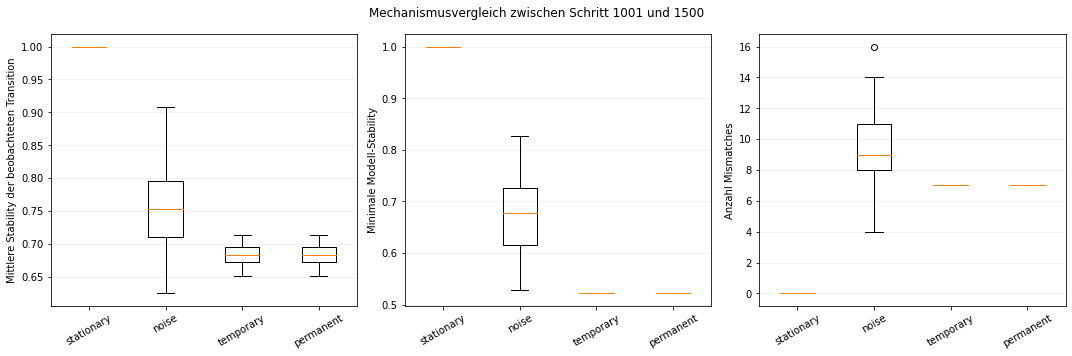

,average_observed_stability,minimum_model_stability,average_mismatches,seeds
world_behavior,,,,
noise,0.757168,0.673837,9.36,50
permanent,0.683161,0.522062,7.00,50
stationary,1.000000,1.000000,0.00,50
temporary,0.683161,0.522062,7.00,50


In [11]:
comparison_window = mechanism_timeline.loc[
    mechanism_timeline["global_step"].between(1001, 1500)
]
mechanism_per_seed = (
    comparison_window.groupby(
        ["experiment_id", "world_behavior", "seed"],
        as_index=False,
    )
    .agg(
        average_observed_stability=(
            "observed_transition_stability",
            "mean",
        ),
        minimum_model_stability=("stability_score", "min"),
        mismatch_count=("mismatch_event", "sum"),
    )
)

figure, axes = plt.subplots(1, 3, figsize=(15, 5))
boxplot_metrics = [
    (
        "average_observed_stability",
        "Mittlere Stability der beobachteten Transition",
    ),
    ("minimum_model_stability", "Minimale Modell-Stability"),
    ("mismatch_count", "Anzahl Mismatches"),
]

for axis, (metric, label) in zip(axes, boxplot_metrics):
    values = [
        mechanism_per_seed.loc[
            mechanism_per_seed["world_behavior"].eq(behavior),
            metric,
        ].dropna()
        for behavior in MECHANISM_BEHAVIORS
    ]
    axis.boxplot(values, labels=MECHANISM_BEHAVIORS)
    axis.set_ylabel(label)
    axis.tick_params(axis="x", rotation=30)
    axis.grid(axis="y", alpha=0.2)

figure.suptitle("Mechanismusvergleich zwischen Schritt 1001 und 1500")
figure.tight_layout()
plt.show()

display(
    mechanism_per_seed.groupby("world_behavior")
    .agg(
        average_observed_stability=(
            "average_observed_stability",
            "mean",
        ),
        minimum_model_stability=(
            "minimum_model_stability",
            "mean",
        ),
        average_mismatches=("mismatch_count", "mean"),
        seeds=("seed", "nunique"),
    )
)